### Minicurso Sistemas Multi-agente com LangGraph

## Grafo com múltiplos nós e nó decisor

Moacir Antonelli Ponti - 2025

--- 

In [10]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


Podemos definir várias funções que representam nós do grafo e conectá-las num fluxo que seja adequado para o problema.

Vamos definir nós para soma e subtração, e um estado que contem a operação executada

In [35]:
class AgentState(TypedDict):
    values: List[float]
    operation: str
    result: str

def op_soma(state: AgentState) -> AgentState:
    """Soma dos valores no estado e atualiza o resultado."""
    total = sum(state['values'])
    state['result'] = f'Resultado = {total}'
    return state

def op_subtracao(state: AgentState) -> AgentState:
    """Subtrai cada valor da lista no estado e atualiza o resultado"""
    total = state['values'][0]
    for value in state['values'][1:]:
        total -= value
    state['result'] = f'Resultado = {total}'
    return state

def decisor_operacao(state: AgentState) -> str:
    """Decide qual operacao realizar com base no estado de 'operation'
        no add_conditional_edges, o retorno será a chave do path_map
    """
    print(f"Estado atual: {state}")
    if state['operation'] == '+':
        return 'SOMA'
    elif state['operation'] == '-':
        return 'SUBTRACAO'
    else:
        return 'INVALIDA'

A aresta condicional `add_conditional_edges` permite rotear entre nós

In [36]:
graph = StateGraph(AgentState)

graph.add_node(node="no_soma", action=op_soma)
graph.add_node(node="no_subtracao", action=op_subtracao)
#graph.add_node(node="roteador", action=decisor_operacao) ## nao posso adicionar como no pois nao retorna estado
graph.add_node("roteador", lambda state:state) # nó "dummy" que apenas repassa o estado como uma funcao identidade

graph.add_edge(START, "roteador")

graph.add_conditional_edges(
    source="roteador",
    path=decisor_operacao,
    path_map= {
        "SOMA": "no_soma",
        "SUBTRACAO": "no_subtracao",
        "INVALIDA": END
    }
)

graph.add_edge("no_soma", END)
graph.add_edge("no_subtracao", END)

app = graph.compile()

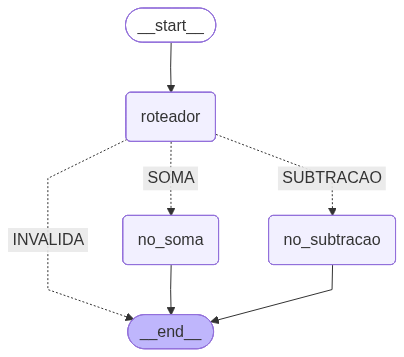

In [37]:
display(Image(app.get_graph().draw_mermaid_png()))

In [38]:
res = app.invoke({"operation":"+", "values":[10,20,30]})
print(res['result'])
res = app.invoke({"operation":"-", "values":[10,20,30]})
print(res['result'])

Estado atual: {'values': [10, 20, 30], 'operation': '+'}
Resultado = 60
Estado atual: {'values': [10, 20, 30], 'operation': '-'}
Resultado = -40


In [27]:
res = app.invoke({"operation":"/", "values":[100,20,30]})
print(res)

{'values': [100, 20, 30], 'operation': '/'}


## Exercício: 

Após a primeira operação, realizar uma segunda, que será dividir o valor por 100 se a primeira tiver sido `+` ou multiplicar por 100 se a primeira tiver sido `-`

roteador - SOMA -> no_soma -> END
         - SUBTRACAO -> no subtracao -> END

roteador - SOMA -> no_soma -> no_divisao -> END
         - SUBTRACAO -> no subtracao -> no_multiplicacao ->END

**tentem fazer assim:**
roteador - SOMA -> no_soma           -> roteador2
         - SUBTRACAO -> no subtracao -> roteador2 - MULTIPLICA -> no_mult -> END
                                                  - DIVIDE -> no_div -> END

In [39]:
def decisor_operacao2(state: AgentState) -> str:
    """Decide qual segunda operacao realizar com base no estado de 'operation'
    """
    print(f"Estado atual: {state}")
    if state['operation'] == '+':
        return 'DIVIDE'
    elif state['operation'] == '-':
        return 'MULTIPLICA'

def _extrai_resultado(resultado : str) -> float:    
    return float(resultado.split('=')[1].strip())

def op_divisao(state: AgentState) -> AgentState:
    """Divide o resultado por 100"""
    current_result = _extrai_resultado(state['result'])
    state['result'] = f'Resultado final = {current_result/100}'
    return state

def op_multiplicacao(state: AgentState) -> AgentState:
    """Multiplica o resultado por 100"""
    current_result = _extrai_resultado(state['result'])
    state['result'] = f'Resultado final = {current_result*100}'
    return state


In [40]:
graph = StateGraph(AgentState)

graph.add_node(node="no_soma", action=op_soma)
graph.add_node(node="no_subtracao", action=op_subtracao)
graph.add_node("roteador", lambda state:state) # nó "dummy" que apenas repassa o estado como uma funcao identidade

graph.add_edge(START, "roteador")

graph.add_conditional_edges(
    source="roteador",
    path=decisor_operacao,
    path_map= {
        "SOMA": "no_soma",
        "SUBTRACAO": "no_subtracao",
        "INVALIDA": END
    }
)

graph.add_node("roteador2", lambda state:state) 
graph.add_edge("no_soma", "roteador2")
graph.add_edge("no_subtracao", "roteador2")

graph.add_node(node="no_mult", action=op_multiplicacao)
graph.add_node(node="no_div", action=op_divisao)

graph.add_conditional_edges(
    source="roteador2",
    path=decisor_operacao2,
    path_map= {
        "MULTIPLICA": "no_mult",
        "DIVIDE": "no_div"
    }
)
graph.add_edge("no_mult", END)
graph.add_edge("no_div", END)

app = graph.compile()


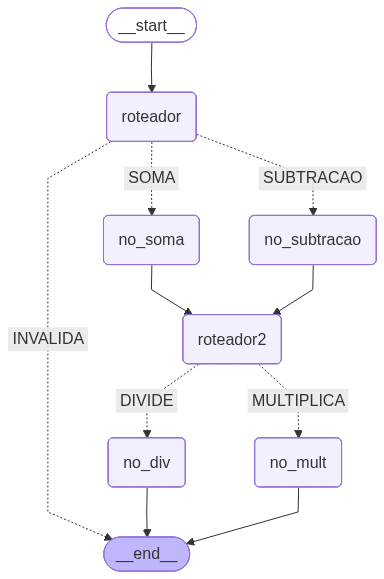

In [41]:
display(Image(app.get_graph().draw_mermaid_png()))

In [42]:
res = app.invoke({"operation":"+", "values":[10,20,30]})
print(res['result']) 

Estado atual: {'values': [10, 20, 30], 'operation': '+'}
Estado atual: {'values': [10, 20, 30], 'operation': '+', 'result': 'Resultado = 60'}
Resultado final = 0.6


In [43]:
res = app.invoke({"operation":"-", "values":[10,20,30]})
print(res['result']) 

Estado atual: {'values': [10, 20, 30], 'operation': '-'}
Estado atual: {'values': [10, 20, 30], 'operation': '-', 'result': 'Resultado = -40'}
Resultado final = -4000.0


In [ ]:
def decisor_operacao2(state: AgentState) -> str:
    """Decide a segunda operação com base na primeira."""
    if state['operation'] == '+':
        return 'mult'
    elif state['operation'] == '-':
        return 'div'
    
def op_multiply(state: AgentState) -> AgentState:
    """Multiplica o resultado por 100."""
    current_result = int(state['result'].split('=')[1].strip())
    new_result = current_result * 100
    state['result'] = f"Resultado = {new_result}"
    return state

def op_divide(state: AgentState) -> AgentState:
    """Divide o resultado por 100."""
    current_result = int(state['result'].split('=')[1].strip())
    new_result = current_result / 100
    state['result'] = f"Resultado = {new_result}"
    return state

In [ ]:
graph = StateGraph(AgentState)

graph.add_node(node="soma", action=op_soma)
graph.add_node(node="subtracao", action=op_subtracao)
# graph.add_node(node="roteador", action=decisor_operacao) # nao funciona pois nao retorna estado
graph.add_node("roteador1", lambda state:state) # funcao dummy para o roteador
graph.add_node("roteador2", lambda state:state) # funcao dummy para o roteador

graph.add_edge(START, "roteador1")
graph.add_conditional_edges(
    source="roteador1",
    path=decisor_operacao,
    path_map={
        'soma': 'soma',
        'subtracao': 'subtracao'}
)

graph.add_edge("soma", "roteador2")
graph.add_edge("subtracao", "roteador2")

graph.add_node(node="multiplica", action=op_multiply)
graph.add_node(node="divide", action=op_divide)

graph.add_conditional_edges(
    source="roteador2",
    path=decisor_operacao2,
    path_map={"mult":"multiplica",
              "div":"divide"
            },
)    

graph.add_edge("multiplica", END)
graph.add_edge("divide", END)

app = graph.compile()

In [ ]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
res = app.invoke({"operation":"+", "values":[10,20,30]})
print(res['result']) 

In [ ]:
res = app.invoke({"operation":"-", "values":[100,20,30]})
print(res['result']) 